<a href="https://colab.research.google.com/github/NSCC-ITC-Fall2025-DBAS5115-700-MCr/assignment-2-emppacs/blob/main/BonusAssign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Exploratory Data Analysis and Preprocessing for Predictive Modeling

**Dataset:** [Impact of Remote Work on Mental Health]("https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health")

**Model Used:** Decision Tree



#**1. Import Key Libraries**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier,  plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
#!pip install ydata-profiling
#!pip install ipywidgets
from ydata_profiling import ProfileReport
import plotly.express as px

#**2. Read / Load Data**

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/NSCC-ITC-Fall2025-DBAS5115-700-MCr/assignment-2-emppacs/refs/heads/main/heart_disease_uci.csv?token=GHSAT0AAAAAADPKGJHW4CNW2PTMBQOYVUEG2JWFRCA")
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


#**3. Exploratory Data Analysis (EDA) and Visualization**

####***3a. Check for Missing Values***

In [33]:
# Initial Null Check:
print(df.info())

# check data shape:
print("\n\n")
print(f"="*50)
print(f"Data Shape: {df.shape}")
print(f"="*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None



Data Shape: (920, 16)


*to further check if there are missing values:*

In [32]:
missing_data = df.isnull().sum()
print(missing_data)
print("\n\n")
print(f"="*50)
print(f"Missing Data:")
print(f"="*50)
print(missing_data[missing_data > 0])

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64



Missing Data:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


*from the result, we can see two fields that has missing values: Mental_Health_Condition (1196) and Physical_Activity (1629)*





*We will deal with it later, for now, let's visualize the data distributions, relationships, and outliers using Seaborn and Plotly*

***Visualize the Missing Values***

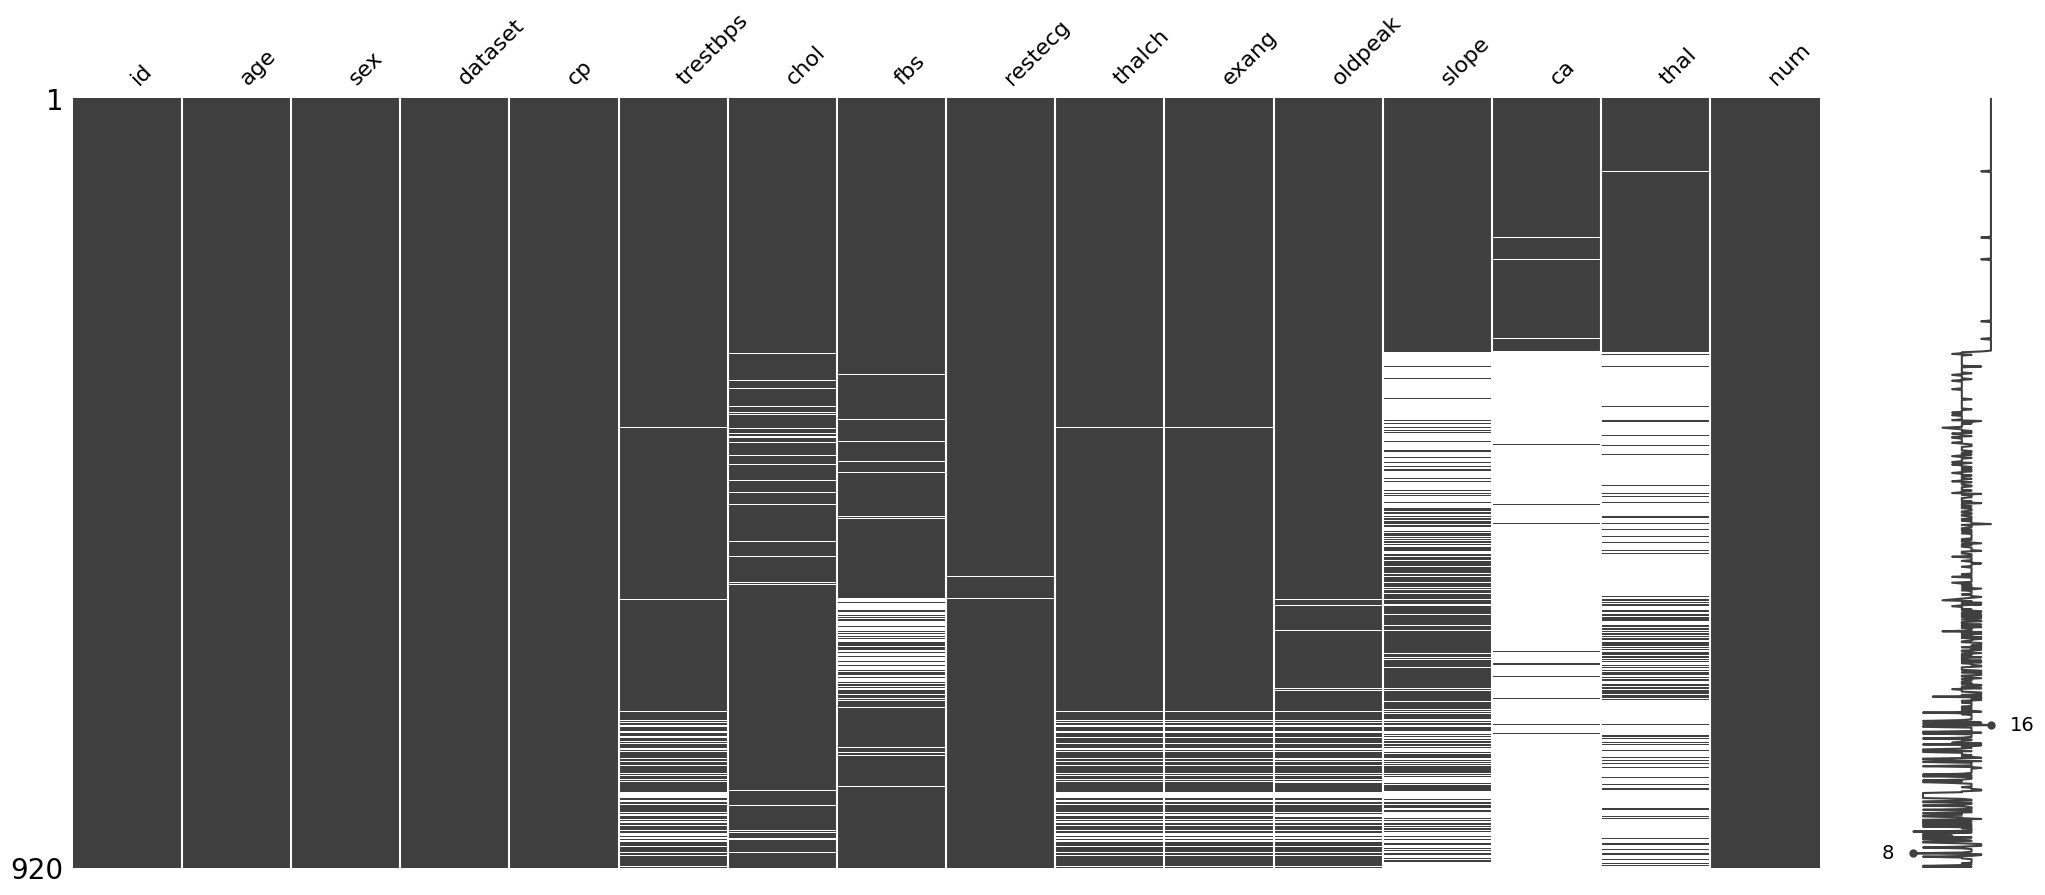

In [6]:
import missingno as msno
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'png'

msno.matrix(df)
plt.show()

####***3b. YData profiling***

In [ ]:
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
#profile.to_file("pandas_profiling_report.html")
profile.to_notebook_iframe()

####***3c. Visualize Data Distribution***

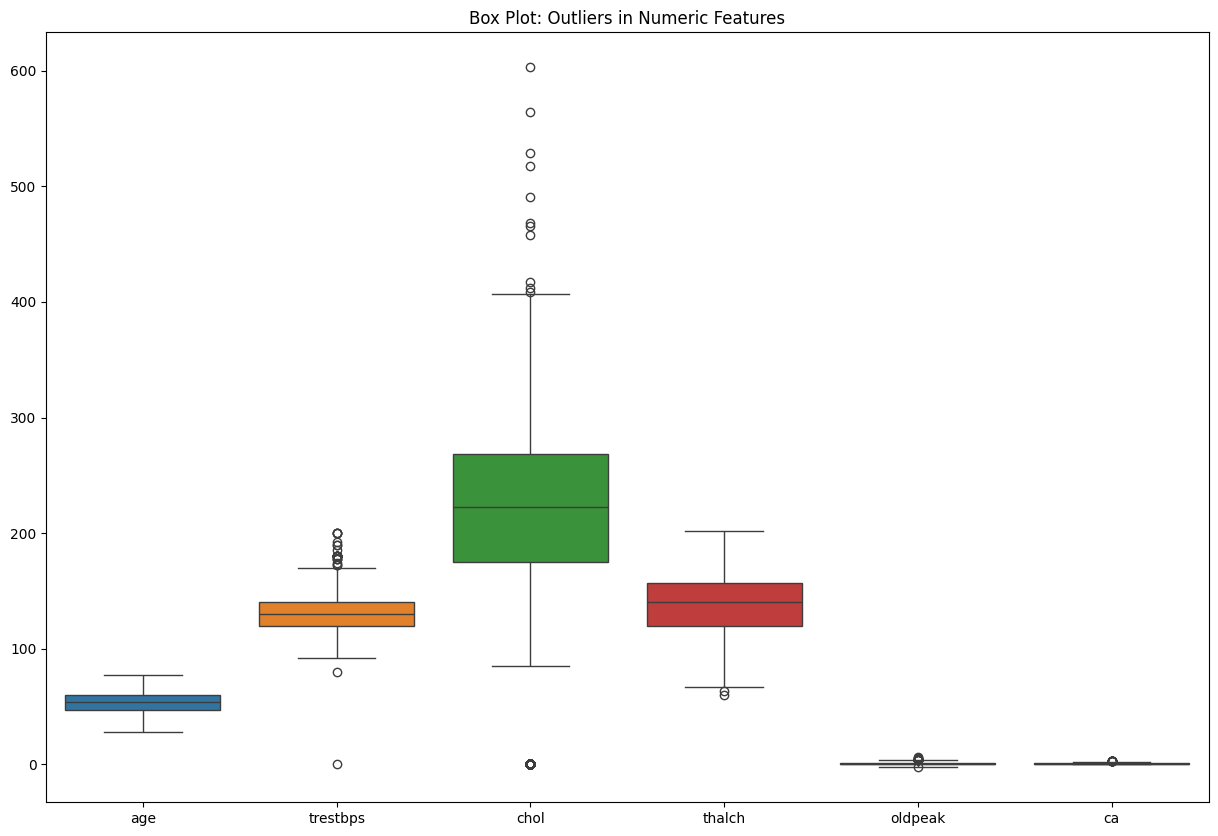

In [63]:
#1. Box Plot for Outliers in Hours_Worked_Per_Week

# plt.figure(figsize=(10,6))
# sns.boxplot(x=df['Hours_Worked_Per_Week'])
# plt.title("Box Plot: Outliers in Hours_Worked_Per_Week")
# plt.xlabel("Hours Worked Per Week")
# plt.show()

# USING THE NEW DATASET:
# 1. Outlier Visualization Using Box Plots (Heart Disease Dataset)

# get numeric columns first (except id)
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

plt.figure(figsize=(15,10))
sns.boxplot(data=df[numeric_cols])
plt.title("Box Plot: Outliers in Numeric Features")
plt.show()

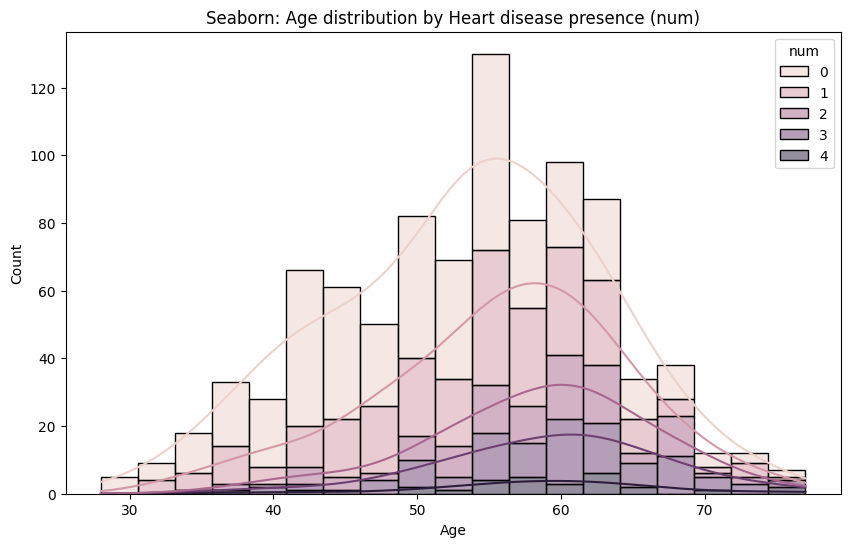

In [19]:
# 2. Histogram: Hours_Worked_Per_Week Distribution by Stress Level
# plt.figure(figsize=(10, 6))

# # Use 'hue' to separate the distributions by the target variable
# sns.histplot(
#     data=df,
#     x='Hours_Worked_Per_Week',
#     hue='Stress_Level',
#     multiple='stack', # 'stack' or 'dodge' are good options
#     kde=True
# )
# plt.title("Seaborn: Hours Worked Per Week Distribution by Stress Level")
# plt.xlabel("Hours_Worked_Per_Week")
# plt.show()




# USING THE NEW DATASET:
# Histogram: Age distribution by Heart disease presence (num)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='age',
    hue='num',
    multiple='stack', # 'stack' or 'dodge' are good options
    kde=True
)
plt.title("Seaborn: Age distribution by Heart disease presence (num)")
plt.xlabel("Age")
plt.show()

In [24]:
# 3. Plotly Density Heatmap: Relationship between Hours Worked and Work Life Balance Rating vs. Stress Level
# Use a density heatmap to show where the points are most frequent
# fig = px.density_heatmap(
#     df,
#     x='Hours_Worked_Per_Week',
#     y='Work_Life_Balance_Rating',
#     facet_col='Stress_Level',
#     title='Density of Stress Levels Across Hours and WLB Rating',
#     template='plotly_dark'
# )

# fig.show()



# USING THE NEW DATASET:
# Density heatmap: Age vs Chol by Heart Disease
fig = px.density_heatmap(
    df,
    x='age',
    y='chol',
    facet_col='num',
    title='Density of Age vs Chol by Heart Disease (num)',
    template='plotly_dark'
)

fig.show()

#**4. Defining X and y (Features and Target)**

In [49]:
# # target column is Stress_Level
# target_col = 'Stress_Level'

# # Drop not relevant columns
# df.drop(columns=['Employee_ID'])

# # split into X and y: X will be all columns EXCEPT the identifier and the target
# X = df.drop(target_col, axis=1)
# y = df[target_col]

# print(f"Target variable defined as: {y.name}")
# print(f"X (Features) shape: {X.shape}")


# USING THE NEW DATASET
# Convert 'num' to binary target
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

#target column is num
target_col = 'num'

# Drop not relevant columns like id
df.drop(columns=['id'])

# split into X and y: X will be all columns EXCEPT the identifier and the target
X = df.drop(target_col, axis=1)
y = df[target_col]

print(f"Target variable defined as: {y.name}")
print(f"X (Features) shape: {X.shape}")

Target variable defined as: num
X (Features) shape: (920, 15)


#**5. Splitting the Data**

In [52]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"="*50)
print("Data Splitting Complete!")
print(f"="*50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Data Splitting Complete!
X_train shape: (736, 15)
X_test shape: (184, 15)


#**6. Preprocessing**

In [51]:
# Identify Numeric and Categorical features
# NUMERIC_FEATURES = ['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating', 'Social_Isolation_Rating']
# CATEGORICAL_FEATURES = ['Gender', 'Job_Role', 'Industry', 'Work_Location', 'Mental_Health_Condition', 'Access_to_Mental_Health_Resources', 'Productivity_Change', 'Satisfaction_with_Remote_Work', 'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality', 'Region']



# USING THE NEW DATASET
# Identify Numeric and Categorical features
NUMERIC_FEATURES = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
CATEGORICAL_FEATURES = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# add
# Convert all categorical columns to string in one line
X[CATEGORICAL_FEATURES] = X[CATEGORICAL_FEATURES].astype(str)


####***6a. Numeric Pipeline: Handles Scaling and Numeric Nulls***

In [53]:
# create pipeline for numeric nulls
numeric_pipeline = Pipeline(steps=[

    # Handles null values: Use median for robustness against outliers
    ('imputer' , SimpleImputer(strategy='median')),

    # normalize and scale numeric values
    ('scaler', RobustScaler())

]
)

####***6b. Categorical Pipeline: (Handles Encoding and Categorical Nulls)***

In [54]:
# create pipeline for categorical nulls
categorical_pipeline = Pipeline(steps=[

    # Handles null values: Impute with 'Unknown' to preserve missingness information
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),

    # Encodes categorical features into numerical format
    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

####***6c. Combine both preprocessed numerical and categorical data using Column Transformer module***

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_FEATURES),
        ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
    ]
)

####***6d. Integrate the Preprocessed Features and Random Forest Classifier Using Pipelines***

In [57]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42))
])

print("Final Modeling Pipeline Successfully Constructed and Ready for Training.")

Final Modeling Pipeline Successfully Constructed and Ready for Training.


#**7. Model Construction and Evaluation**

In [59]:
print(f"="*50)
print("Training Random Forest Pipeline...")
print(f"="*50)

clf.fit(X_train, y_train)

Training Random Forest Pipeline...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=150, random_state=42))])

In [60]:
# Prediction
y_pred = clf.predict(X_test)

# Model Performance
print(f"="*50)
print("MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER")
print(f"="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion matrix
cm = (confusion_matrix(y_test, y_pred))
print("\nConfusion Matrix:")
print(cm)

MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER
Accuracy: 0.842391304347826

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
[[66 16]
 [13 89]]


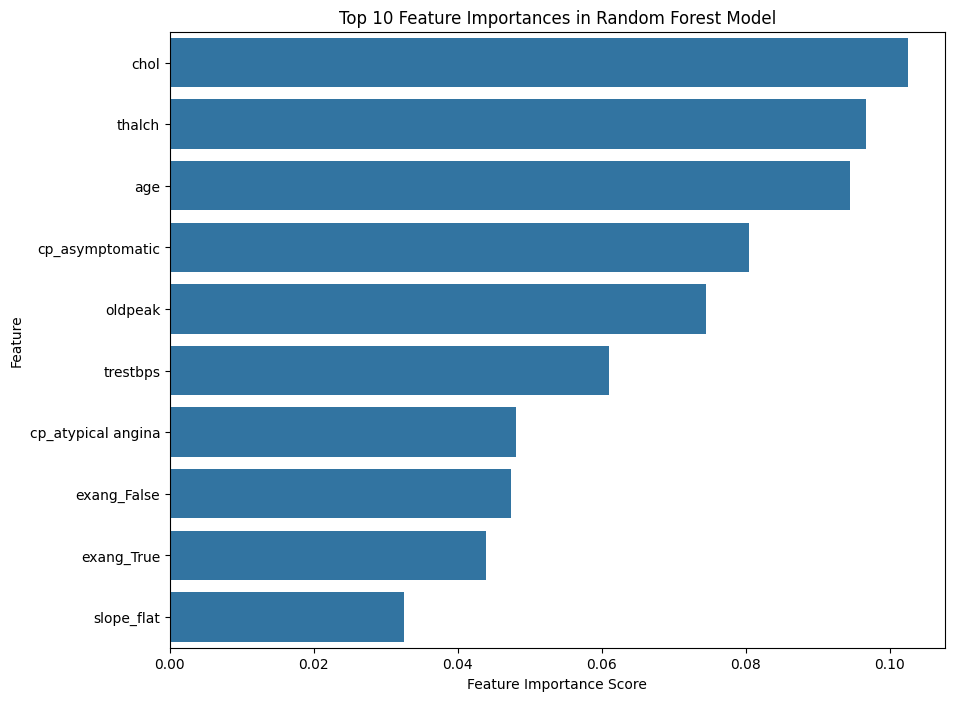

In [61]:
# feature importance

final_model = clf.named_steps['classifier']
preprocessor_fitted = clf.named_steps['preprocessor']


importances = final_model.feature_importances_


numeric_features_out = NUMERIC_FEATURES
onehot_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
categorical_features_out = list(onehot_encoder.get_feature_names_out(CATEGORICAL_FEATURES))


feature_names_out = numeric_features_out + categorical_features_out


feature_importance_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Plotting the Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
)
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()

In [62]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_split': [5, 10],
}

# Integrate GridSearchCV into the final pipeline setup
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5, # Use 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1 # Use all processors
)

# Train the Grid Search (This takes much longer than a simple .fit)
print("Starting GridSearchCV for Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Use the best model found by the search
best_model = grid_search.best_estimator_

# Evaluation using the best model
y_pred_tuned = best_model.predict(X_test)

print("\n" + "="*50)
print("MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER (TUNED)")
print("="*50)
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Tuned Accuracy on Test Set: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Starting GridSearchCV for Hyperparameter Tuning...

MODEL PERFORMANCE: RANDOM FOREST CLASSIFIER (TUNED)
Best Parameters Found: {'classifier__max_depth': 8, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Tuned Accuracy on Test Set: 0.8533

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

